---
title: "Chapter 5: Unsupervised Learning. Part 1"
subtitle: "Machine Learning"
date: "April 2026"
date-format: "MMMM YYYY"
author: 
  - F.San Segundo & N.Rodríguez
execute:
  echo: true
code-overflow: wrap
format: 
  beamer:
    linkcolor: orange
    theme: Madrid
    keep-tex: true
    pdf-engine: lualatex
    fig-align: center
    fontsize: 8pt
    include-in-header:
        - file: "../beamer-header-simple.txt"
  pdf:
    toc: true
    linkcolor: orange
    fig-align: center
    fontsize: 10pt
  html: 
    toc: true
    code-tools: true
    embed-resources: true
---

In [85]:
%cd 5_1_Unsupervised_PCA

[Errno 2] No such file or directory: '5_1_Unsupervised_PCA'
/wd/5_1_Unsupervised_PCA


---


::: {.callout-note icon=false}

## John Naisbitt

"We are drowning in information and starving for knowledge."
::: 
---

- **Machine Learning:** set of methods that can automatically detect patterns in data and then use them to predict future data or perform other kinds of decision making under uncertainty.

- **Types:**
    1. **Predictive or supervised learning** - $p(y_{i}|x_{i},\theta)$: learn a mapping from inputs $x$ to outputs $y$, given a labeled set of input-output pairs $D = \{(x_{i}, y_{i})\}_{i=1}^{N}$ training set.  
       - If $y_{i}$ is categorical → classification.  
       - If $y_{i}$ is real-valued → regression.
    2. **Descriptive or unsupervised learning** - $p(x_{i}|\theta)$: only inputs given, $D = \{(x_{i})\}_{i=1}^{N}$ and the goal is to find patterns in the data. Not a well-defined problem: we are not told what kinds of patterns to look for, no obvious error metric to use, no knowledge about the target data.
   
    3. **Reinforcement learning**: an agent learns to make decisions by interacting with an environment.


---

## 5.1. Unsupervised Learning

::: {.callout-note icon=false}

## Geoffrey Hinton

"When we’re learning to see, nobody’s telling us what the right answers are — we just look. Every so often, your mother says “that’s a dog”, but that’s very little information. You’d be lucky if you got a few bits of information — even one bit per second — that way. The brain’s visual system has $10^{14}$ neural connections. And you only live for $10^9$ seconds. So it’s no use learning one bit per second. You need more like $10^5$ bits per second. And there’s only one place you can get that much information: from the input itself."

::: 
---

### We will study two approaches:

1. **Discovering latent factors:** When handling high-dimensional data, it's often helpful to perform dimensionality reduction by projecting it into a lower-dimensional subspace, latent factors; this is known as dimensionality reduction. (**PCA**)

2. **Discovering clusters:**  Our first goal is to estimate the distribution over the number of clusters, this tells us if there are sub-populations within the data. Our second goal is to estimate which cluster each point belongs to. (**KMEANS**)

---

![batmanmeme](https://miro.medium.com/v2/resize:fit:508/1*eEZAigUW7zDCK_1DLnmBdw.jpeg)




# 5.2. Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a statistical procedure that uses an orthogonal transformation to convert a set of observations of possibly correlated variables into a set of values of linearly uncorrelated variables called principal components. This technique is widely used in data analysis and for making predictive models. Its key aspects:

1. **Dimensionality Reduction**: One of the most common uses of PCA is to reduce the dimensionality of a dataset while retaining as much of the variability in the dataset as possible. This is achieved by transforming to a new set of variables, the principal components, which are orthogonal (uncorrelated), with the first few retaining most of the variation present in all of the original variables.

2. **Feature Extraction**: PCA can be used to discover or reduce the dimensionality of the data space, identifying the most significant features that explain the majority of the variability in the data.

3. **Visualization**: In datasets with many variables, PCA allows for the visualization of the structure of the data, identifying patterns and possible correlations between variables.

4. **Noise Reduction**: By keeping only the most significant principal components and ignoring the rest, PCA can help in filtering out noise from the data.




Motivation to downsize:

- **High dimensional data**: in machine learning, working with data sets containing a large number of variables is common. These variables represent multiple dimensions of information.
- **Possible correlation and redundancy**: In situations with many variables, some are likely to be highly correlated, leading to redundant information in the dataset.
- **Management and efficiency problem**: The main problem lies in the difficulty to efficiently handle high dimensionality datasets, as this can increase computational complexity, hinder the interpretation of results, and generate less accurate models due to redundancy and noise present in the data.


Dimensionality reduction, and PCA in particular, has been applied in many different areas. Some examples include the following:

- In biology, it is common to use PCA to interpret gene microarray data, to account for the fact that each measurement is usually the result of many genes which are correlated in their behavior by the fact that they belong to different biological pathways.
- In natural language processing, it is common to use a variant of PCA called latent semantic analysis for document retrieval.
- In signal processing (e.g., of acoustic or neural signals), it is common to use ICA (which is a variant of PCA) to separate signals into their different sources.
- In computer graphics, it is common to project motion capture data to a low dimensional space, and use it to create animations.

::: {.callout-note icon=false}

## Steps for PCA

1. Standardize the range of continuous initial variables.
2. Compute the covariance matrix to identify correlations.
3. Compute the eigenvectors and eigenvalues of the covariance matrix to identify the principal components.
4. Sort the eigenvalues by decreasing order to rank the corresponding eigenvectors.
5. Select $k$ eigenvectors, which correspond to the $k$ largest eigenvalues, where $k$ is the dimensionality of the new feature subspace.
6. Construct a projection matrix $W$ from the "top" $k$ eigenvectors. This matrix will be $d$ x $k$

::: 

- We have a feature vector $\vec{x}$:   
$$\vec{x} = \left[x_1,x_2,...,x_d\right], \vec{x}\in \mathbb{R}^{d}$$
- We assume that $\vec{x}$ has already standardized the values of the features. 
- $\vec{x}$ can be transformed by a transformation matrix, $W\in \mathbb{R}^{d\text{x} k}$: 
$$\vec{x} W = \vec{z}$$
- The output vector $\vec{z}$:  
$$\vec{z} = \left[z_1,z_2,...,z_k\right], \vec{z}\in \mathbb{R}^{k}$$
- Where $W$ is the matrix containing the $k$ eigenvectors with the largest eigenvalues of the empirical covariance matrix.

To decode:

$$\vec{x} = \vec{z} W^T$$


In summary: *PCA finds the directions of maximal variance.*

 ::: {.callout-note icon=false}

 ##### Explained variance


 Since, for $W$, we only select the subset of eigenvectors that contains most of the variance, we have to sort the eigenvalues by decreasing magnitude. We are interested in the top $k$ eigenvectors. To determine $k$, we will have to calculte the **variance explained ratios** of the eigenvalues. 

 $$\text{Explained variance ratio} = \frac{\lambda_j}{\sum_{j=1}^{d}\lambda_j}$$

::: 


### **Example 1**

Before using scikit-learn, let's start by manually calculating the principal components for a dataset. We do not have any specific objective of analysis for this dataset; we are using it just to show the calculation process of the principal components. 

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [87]:
%run data1.py

In [88]:
X.shape

(200, 2)

**1. Standardize the range of continuous initial variables.**

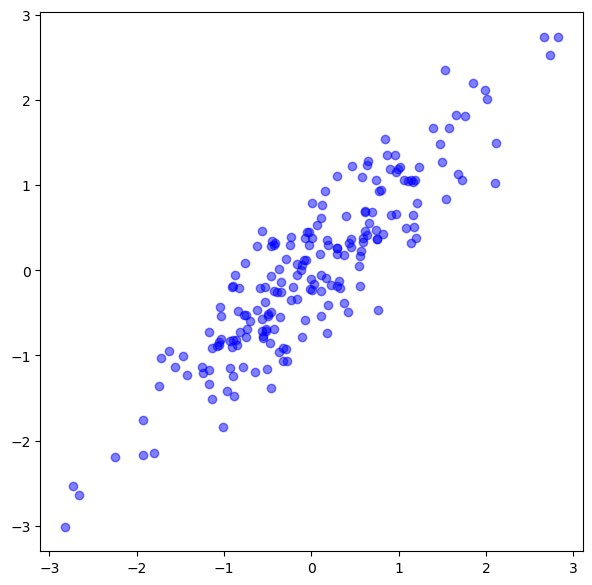

In [89]:
X_std = StandardScaler().fit_transform(X)

plt.figure(figsize=(7, 7))
plt.plot(X_std[:, 0], X_std[:, 1], "bo", alpha=0.5)
plt.show()

**2. Compute the covariance matrix to identify correlations.**

In [90]:
cov_mat = np.cov(X_std.T)
print('Covariance matrix \n%s' %cov_mat)

Covariance matrix 
[[1.00502513 0.90575658]
 [0.90575658 1.00502513]]


**3. Compute the eigenvectors and eigenvalues of the covariance matrix to identify the principal components.**

In [91]:
eig_vals, eig_vecs = np.linalg.eig(cov_mat)
print('Eigenvectors \n%s' %eig_vecs)
print('\nEigenvalues \n%s' %eig_vals)

Eigenvectors 
[[-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]

Eigenvalues 
[0.09926855 1.9107817 ]


**4. Sort the eigenvalues by decreasing order to rank the corresponding eigenvectors.**

In [92]:
# Make a list of (eigenvalue, eigenvector) tuples
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:,i]) for i in range(len(eig_vals))]

# Sort the (eigenvalue, eigenvector) tuples from high to low
eig_pairs.sort(key=lambda x: x[0], reverse=True)

# Visually confirm that the list is correctly sorted by decreasing eigenvalues
print('Eigenvalues in descending order:')
for i in eig_pairs:
    print(i[0])

Eigenvalues in descending order:
1.9107817040282038
0.0992685472280781


We only select the subset of the eigenvectors (principal components) that contains most of the information (variance). To identify this subset, we have to calculate the variance explained ratios, which show how much variance each principal component explains. 

In [93]:
tot = sum(eig_vals)
var_exp = [(i / tot)*100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print(var_exp)

[np.float64(95.0613897754031), np.float64(4.938610224596884)]


It can be better interpreted through a plot. 

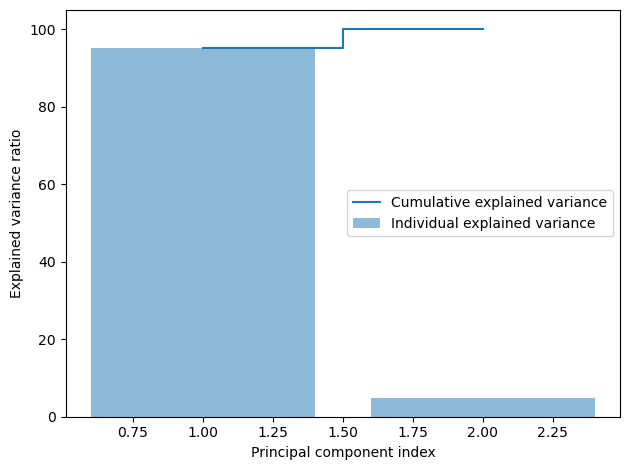

In [94]:
plt.bar(range(1,3), var_exp, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1,3), cum_var_exp, where='mid', label="Cumulative explained variance")
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc="best")
plt.tight_layout()

Now, we can identify the two eigenvectors:

In [95]:
# projection onto eigenvectors
u1 = eig_vecs[0]
u2 = eig_vecs[1]

u1, u2

(array([-0.70710678, -0.70710678]), array([ 0.70710678, -0.70710678]))

We can project the values in X in these principal components

In [96]:
X_proj1 = X_std.dot(u1.reshape(-1, 1))
X_proj2 = X_std.dot(u2.reshape(-1, 1))

X_proj1

array([[-2.52468946],
       [ 0.01098457],
       [ 0.40992497],
       [ 0.16118369],
       [ 0.09510775],
       [ 1.75127029],
       [-1.36555162],
       [-0.04112863],
       [ 0.8776719 ],
       [-1.28117063],
       [ 1.65944936],
       [-2.08832552],
       [ 1.47591193],
       [-0.86007986],
       [ 1.08295622],
       [-1.19749671],
       [ 1.7752099 ],
       [ 1.30659947],
       [ 1.36180977],
       [-1.55549987],
       [ 2.20033197],
       [ 0.63060906],
       [ 0.8723343 ],
       [ 1.20817117],
       [ 3.14205431],
       [-1.48028448],
       [-1.63364413],
       [-1.9818786 ],
       [-1.03064069],
       [ 0.98705483],
       [-1.5673466 ],
       [ 0.12845165],
       [ 0.9217177 ],
       [-0.13140079],
       [-0.76770968],
       [ 1.34853675],
       [ 0.06922029],
       [-0.73041385],
       [-0.91774566],
       [ 1.82453482],
       [ 1.8818932 ],
       [-0.79037497],
       [-0.29898567],
       [ 0.10062021],
       [ 4.12602701],
       [ 0

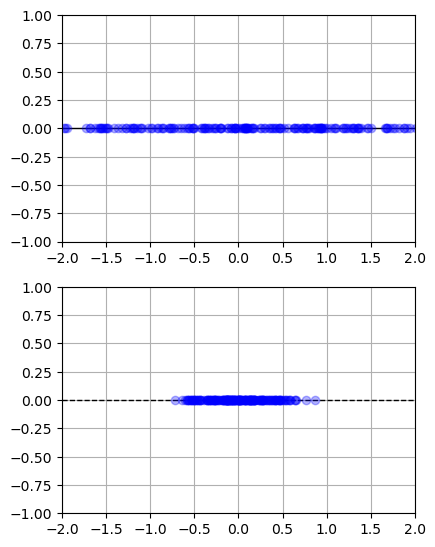

In [97]:
plt.figure(figsize=(10, 10))
plt.subplot2grid((3, 2), (0, 1))
plt.plot([-2, 2], [0, 0], "k-", linewidth=1)
plt.plot(X_proj1[:, 0], np.zeros(m), "bo", alpha=0.3)
plt.axis([-2, 2, -1, 1])
plt.grid(True)

plt.subplot2grid((3, 2), (1, 1))
plt.plot([-2, 2], [0, 0], "k--", linewidth=1)
plt.plot(X_proj2[:, 0], np.zeros(m), "bo", alpha=0.3)
plt.axis([-2, 2, -1, 1])
plt.grid(True)

In the original scatterplot, we can clearly see the direction of the principal components

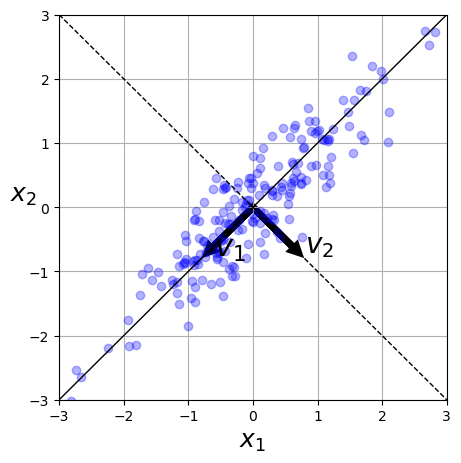

In [98]:
plt.figure(figsize=(5, 5))
plt.plot(X_std[:, 0], X_std[:, 1], "bo", alpha=0.3)
plt.arrow(0, 0, u1[0], u1[1], head_width=0.1, linewidth=5, length_includes_head=True, head_length=0.1, fc="k", ec="k")
plt.arrow(0, 0, u2[0], u2[1], head_width=0.1, linewidth=5, length_includes_head=True, head_length=0.1, fc="k", ec="k")
plt.plot([-4, 4], [-4 * u1[1] / u1[0], 4 * u1[1] / u1[0]], "k-", linewidth=1)
plt.plot([-4, 4], [-4 * u2[1] / u2[0], 4 * u2[1] / u2[0]], "k--", linewidth=1)
plt.grid(True)
plt.text(u1[0] + 0.1, u1[1] - 0.05, r"$v_1$", fontsize=22)
plt.text(u2[0] + 0.1, u2[1], r"$v_2$", fontsize=20)
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$x_2$", fontsize=18, rotation=0)
# Set the axis limits for the plot
plt.axis([-3, 3, -3, 3])
plt.show()

In [99]:
z1 = np.dot(X_std, u1)
z2 = np.dot(X_std, u2)

In [100]:
df = pd.DataFrame({'z1': z1, 'z2': z2})

print('Data in the Latent Space')

df.head(10)

Data in the Latent Space


,z1,z2
0,-2.524689,-0.042300
1,0.010985,0.539478
2,0.409925,0.084989
3,0.161184,0.173243
4,0.095108,0.131856
5,1.751270,-0.324173
6,-1.365552,-0.454856
7,-0.041129,0.115495
8,0.877672,0.416322
9,-1.281171,0.362580


<Axes: xlabel='z1', ylabel='z2'>

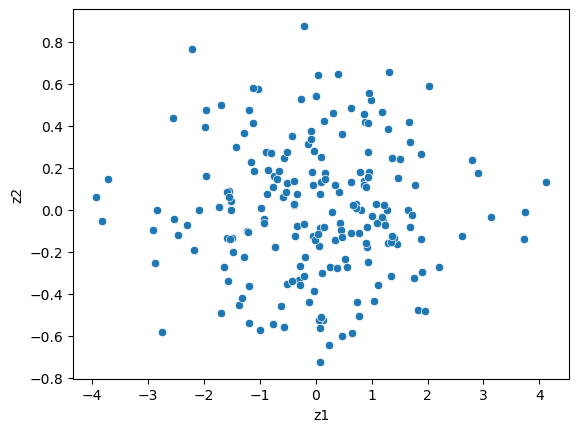

In [101]:
import seaborn as sns

sns.scatterplot(data=df, x='z1', y='z2')

### **Example 2 (IrisDataset)**

Now we will aply PCA to the Iris dataset. Let's first take a look at the dataset.

In [102]:
df = pd.read_csv(
    filepath_or_buffer='https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data',
    header=None,
    sep=',')

In [103]:
df.columns=['sepal_len', 'sepal_wid', 'petal_len', 'petal_wid', 'class']
df.dropna(how="all", inplace=True) # drops the empty line at file-end
df.head()

,sepal_len,sepal_wid,petal_len,petal_wid,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [104]:
X = df.iloc[:,0:4].values
y = df.iloc[:,4].values

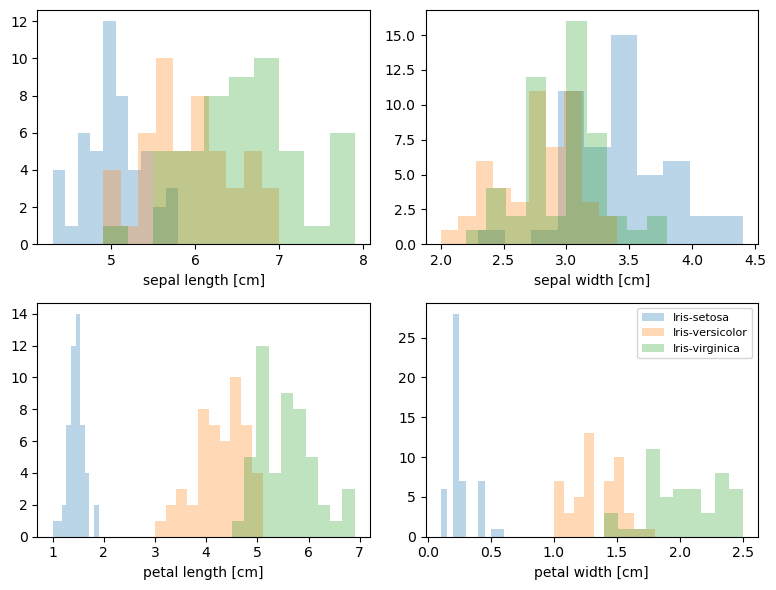

In [105]:
label_dict = {1: 'Iris-Setosa',
              2: 'Iris-Versicolor',
              3: 'Iris-Virgnica'}

feature_dict = {0: 'sepal length [cm]',
                1: 'sepal width [cm]',
                2: 'petal length [cm]',
                3: 'petal width [cm]'}


plt.figure(figsize=(8, 6))
for cnt in range(4):
    plt.subplot(2, 2, cnt+1)
    for lab in ('Iris-setosa', 'Iris-versicolor', 'Iris-virginica'):
        plt.hist(X[y==lab, cnt],
                    label=lab,
                    bins=10,
                    alpha=0.3,)
    plt.xlabel(feature_dict[cnt])
plt.legend(loc='upper right', fancybox=True, fontsize=8)

plt.tight_layout()
plt.show()

First, we standardize the data and calculate the covariance matrix.

In [106]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)

In [107]:
import numpy as np
cov_mat = np.cov(X_std.T)
print('Covariance matrix \n%s' %cov_mat)

Covariance matrix 
[[ 1.00671141 -0.11010327  0.87760486  0.82344326]
 [-0.11010327  1.00671141 -0.42333835 -0.358937  ]
 [ 0.87760486 -0.42333835  1.00671141  0.96921855]
 [ 0.82344326 -0.358937    0.96921855  1.00671141]]


Then, we calculate the eigenvectors and eigenvalues of the covariance matrix.

In [108]:
eig_vals, eig_vecs = np.linalg.eig(cov_mat)
print('Eigenvectors \n%s' %eig_vecs)
print('\nEigenvalues \n%s' %eig_vals)

Eigenvectors 
[[ 0.52237162 -0.37231836 -0.72101681  0.26199559]
 [-0.26335492 -0.92555649  0.24203288 -0.12413481]
 [ 0.58125401 -0.02109478  0.14089226 -0.80115427]
 [ 0.56561105 -0.06541577  0.6338014   0.52354627]]

Eigenvalues 
[2.93035378 0.92740362 0.14834223 0.02074601]


And finally, we sort the eigenvalues by decreasing order to rank the corresponding eigenvectors.

In [109]:
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:,i]) for i in range(len(eig_vals))]
eig_pairs.sort(key=lambda x: x[0], reverse=True)
print('Eigenvalues in descending order:')
for i in eig_pairs:
    print(i[0])

Eigenvalues in descending order:
2.930353775589317
0.9274036215173419
0.14834222648163944
0.02074601399559593


#### Explained variance

We can calculate the explained variance ratio for each principal component.

In [110]:
tot = sum(eig_vals)
var_exp = [(i / tot)*100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print(var_exp)
print(cum_var_exp)

[np.float64(72.77045209380135), np.float64(23.03052326768065), np.float64(3.683831957627379), np.float64(0.5151926808906321)]
[ 72.77045209  95.80097536  99.48480732 100.        ]


And visualize the explained variance ratio.

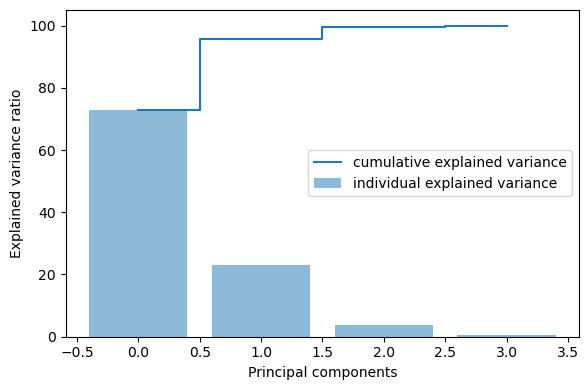

In [111]:
plt.figure(figsize=(6, 4))

plt.bar(range(4), var_exp, alpha=0.5, align='center',
        label='individual explained variance')
plt.step(range(4), cum_var_exp, where='mid',
        label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

We're now at the exciting part: creating the projection matrix to transform the Iris data into a new feature subspace. Despite the sophisticated name, the projection matrix is simply the top k eigenvectors combined. 


In this case, **we're going from a 4-dimensional space down to 2 dimensions** by selecting the two eigenvectors with the highest eigenvalues to form our matrix W. These two principal components explain 95% of the variance, as we could see in the previous plot. 

In [112]:
v1 = eig_pairs[0][1]
print(v1)

[ 0.52237162 -0.26335492  0.58125401  0.56561105]


In [113]:
v2 = eig_pairs[1][1]
print(v2)

[-0.37231836 -0.92555649 -0.02109478 -0.06541577]


The projection matrix would look like this:

In [114]:
matrix_w = np.hstack((v1.reshape(4,1),
                      v2.reshape(4,1)))

print('Matrix W:\n', matrix_w)

Matrix W:
 [[ 0.52237162 -0.37231836]
 [-0.26335492 -0.92555649]
 [ 0.58125401 -0.02109478]
 [ 0.56561105 -0.06541577]]


Then, we can project the Iris data into the new feature subspace.

In [115]:
Z_loadings = np.dot(X_std, matrix_w)

In [116]:
df_Z_loadings = pd.DataFrame(Z_loadings, columns = ['PCA1', 'PCA2'])
df_Z_loadings.head()

,PCA1,PCA2
0,-2.264542,-0.505704
1,-2.086426,0.655405
2,-2.367950,0.318477
3,-2.304197,0.575368
4,-2.388777,-0.674767


And we can plot the new data points in the new feature subspace.

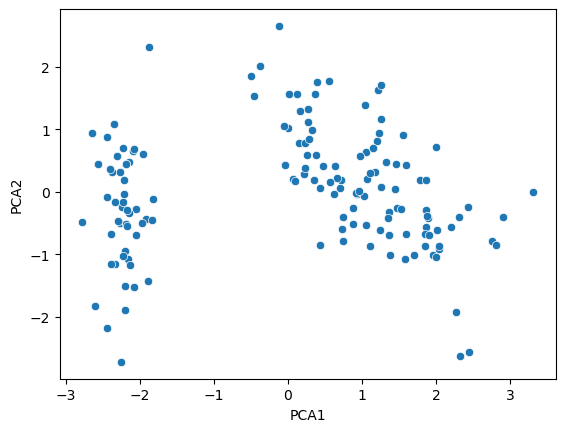

In [117]:
import seaborn as sns

sns.scatterplot(x=df_Z_loadings.iloc[:, 0], y=df_Z_loadings.iloc[:, 1])
plt.show()

In the previous plot we cannot clearly see the advantage of reducing the dimensions. To do so, we have to include the information about our target in the plot (plot below)

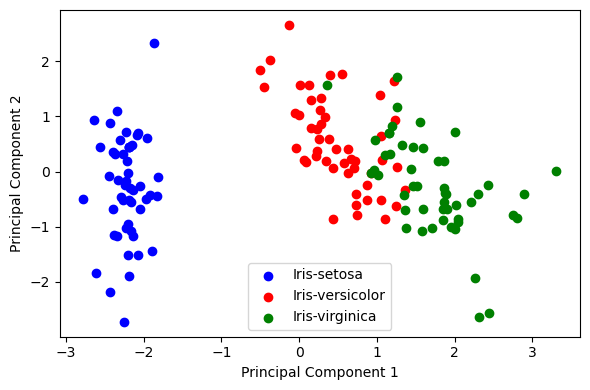

In [118]:
plt.figure(figsize=(6, 4))
for lab, col in zip(('Iris-setosa', 'Iris-versicolor', 'Iris-virginica'),
                    ('blue', 'red', 'green')):
    plt.scatter(Z_loadings[y==lab, 0],
                Z_loadings[y==lab, 1],
                label=lab,
                c=col)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='lower center')
plt.tight_layout()
plt.show()

We can see that by reducing the dimensions of features, the distinction between the different flowers can be observed in 2D. 


Now, let's do this using the functions of sklearn

### sklearn implementation

#####  Analysis of the features' contribution to the principal components

Applying PCA to the dataset is quite straightforward with the `PCA` class from scikit-learn. We can specify the number of principal components we want to keep when creating the PCA object.

In [35]:
from sklearn.decomposition import PCA 

sklearn_pca = PCA(n_components=2)
Y_sklearn = sklearn_pca.fit_transform(X_std)

In [36]:
exp_variance = pd.DataFrame(data=sklearn_pca.explained_variance_ratio_, index = ['PC' + str(n_pca + 1) for n_pca in range(sklearn_pca.n_components)], columns=['Exp_variance'])
exp_variance['cum_Exp_variance'] = exp_variance['Exp_variance'].cumsum()
exp_variance

,Exp_variance,cum_Exp_variance
PC1,0.727705,0.727705
PC2,0.230305,0.958010


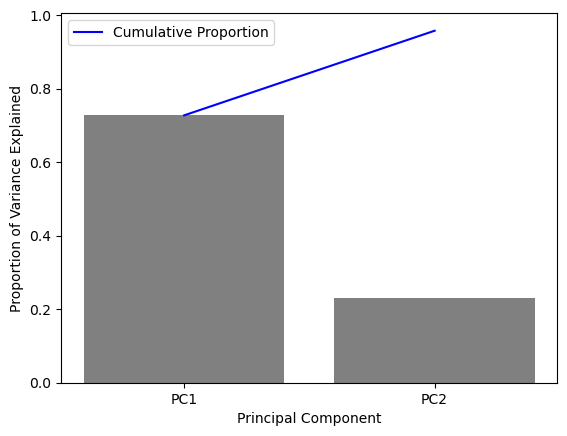

In [37]:
sns.barplot(data=exp_variance, x=exp_variance.index, y='Exp_variance', color='gray')
sns.lineplot(data=exp_variance, x=exp_variance.index, y='cum_Exp_variance', color='blue', label='Cumulative Proportion')
plt.ylabel('Proportion of Variance Explained')
plt.xlabel('Principal Component')
plt.legend()
plt.show()

Let's see in these principal components, how much each feature contributes to the variance in the original data. 

To do this, we are going to multiply the components by the square root of the explained variance (see code below), so that the components are scaled to really reflect their contribution to the variance in the original data.

In [38]:
# Print the PCs scaled to reflect the contribution to the variance
loadings = pd.DataFrame(sklearn_pca.components_.T * np.sqrt(sklearn_pca.explained_variance_), columns=['PC' + str(pca + 1) for pca in range(sklearn_pca.n_components)])
loadings

,PC1,PC2
0,0.894210,0.358549
1,-0.450818,0.891328
2,0.995007,0.020315
3,0.968229,0.062997


In [39]:
from sklearn import datasets

# load features and targets separately
iris = datasets.load_iris()

# Feature names before PCA
feature_names = iris.feature_names

# set index to name of features in
loadings['feature_names'] = feature_names
loadings = loadings.set_index('feature_names')

loadings

,PC1,PC2
feature_names,,
sepal length (cm),0.894210,0.358549
sepal width (cm),-0.450818,0.891328
petal length (cm),0.995007,0.020315
petal width (cm),0.968229,0.062997


We can plot the features' contribution to the principal components through a Loading Plot

 ::: {.callout-note icon=false}

 ##### Interpreting a loading plot
* Variable Relationships: Variables with arrows pointing in similar directions are positively correlated, while those pointing in opposite directions are negatively correlated.
* Variable Importance: The length of the arrow indicates the importance of the variable to the principal component. Longer arrows represent more important variables.
* Variable Contribution: The angle between two arrows indicates the correlation between the variables. The smaller the angle, the higher the correlation.

::: 


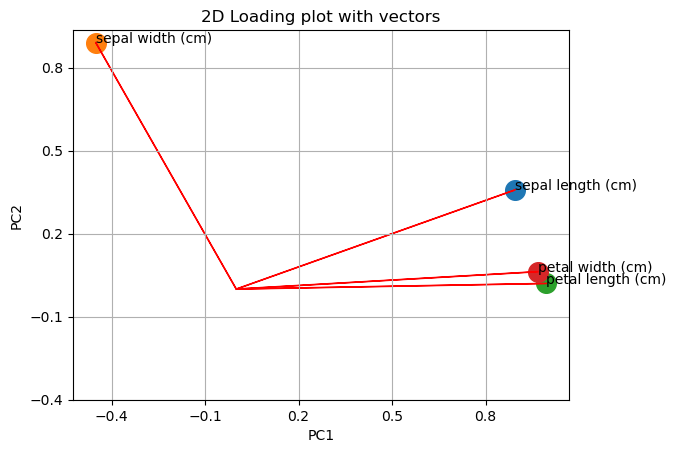

In [40]:
%run -i "5_1_1_LoadingsPlot.py"

#### Accuracy comparison

##### Without PCA

In [119]:
from sklearn.model_selection import train_test_split

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, stratify=y, random_state=42)

In [120]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
preds = clf.predict_proba(X_test)
print('Accuracy Test: {:.5f}'.format(accuracy_score(y_test, preds.argmax(axis=1))))

Accuracy Test: 0.91111


##### With PCA

Let's reduce the dimensionality to 2 dimensions.

In [121]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, stratify=y, random_state=42)


In [122]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

clf = DecisionTreeClassifier(random_state=42) 
clf.fit(X_train_pca, y_train)
preds = clf.predict_proba(X_test_pca)
print('Accuracy Test: {:.5f}'.format(accuracy_score(y_test, preds.argmax(axis=1))))

Accuracy Test: 0.91111


 ::: {.callout-note icon=false}

 ##### Consider that...


Applying PCA can sometimes lead to worse accuracy because it reduces the dimensionality of the data, which may result in the loss of important information. Some reasons why this might happen:

1. **Loss of Information**: PCA transforms the original features into a smaller set of principal components. While this can help in reducing noise and improving computational efficiency, it can also lead to the loss of important information that is crucial for the model's performance.

2. **Variance Preservation**: PCA aims to preserve as much variance as possible, but it does not necessarily preserve the features that are most relevant for the classification task. The principal components that capture the most variance might not be the ones that are most useful for predicting the target variable.

3. **Model Complexity**:For example, the decision tree classifier might perform better with the original features because it can capture complex interactions between them. Reducing the number of features with PCA might oversimplify the problem, leading to worse performance.

4. **Overfitting**: In some cases, the original high-dimensional data might allow the model to overfit to the training data. PCA reduces the dimensionality and can help prevent overfitting, but if the model was already generalizing well, this reduction might hurt performance.

::: 


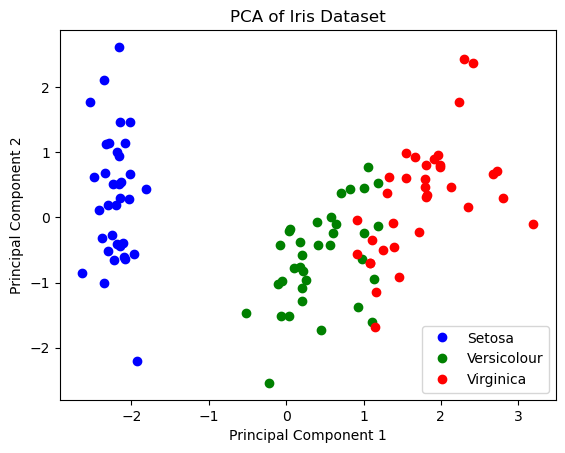

In [45]:

# Plotting the results of PCA
plt.plot(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], 'bo', label='Setosa')
plt.plot(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], 'go', label='Versicolour')
plt.plot(X_train_pca[y_train == 2, 0], X_train_pca[y_train == 2, 1], 'ro', label='Virginica')
plt.legend(loc=0)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.show()

In [46]:
for i, component in enumerate(pca.components_):
    print("{} component: {}% of initial variance".format(i + 1, round(100 * pca.explained_variance_ratio_[i], 2)))
    print(" + ".join("%.3f x %s" % (value, name) for value, name in zip(component, iris.feature_names)))

1 component: 72.64% of initial variance
0.531 x sepal length (cm) + -0.241 x sepal width (cm) + 0.582 x petal length (cm) + 0.567 x petal width (cm)
2 component: 23.38% of initial variance
0.338 x sepal length (cm) + 0.939 x sepal width (cm) + 0.025 x petal length (cm) + 0.057 x petal width (cm)



### **Example 3 (MNIST)**

In this example we are going apply PCA to the MNIST dataset.

 ::: {.callout-note icon=false}

 ##### MNIST dataset

The MNIST dataset is a well-known collection of handwritten digits used for training and testing machine learning models, particularly in the field of image recognition. It contains 60,000 training images and 10,000 testing images, each of which is a 28x28 pixel grayscale image of a digit from 0 to 9.

This dataset is often used as a benchmark for evaluating the performance of various machine learning algorithms.

::: 


The steps we are going to apply are: 
1. Load the MNIST dataset from Keras.
2. Preprocess the data.
3. Apply PCA to reduce the dimensionality.
4. Visualize the results.

In [47]:
try:
    from tensorflow import keras
except ModuleNotFoundError:
    %pip install -qq tensorflow

Note: you may need to restart the kernel to use updated packages.


In [49]:
# Let's load the relevant libraries
import warnings
from sklearn.metrics import mean_squared_error
warnings.simplefilter("ignore", RuntimeWarning)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import keras
import seaborn as sns
from sklearn.decomposition import PCA

First, we will load the MNIST dataset from keras and split it into train and test sets. 

In [50]:
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


::: {.callout-tip  icon=false}

#### Exercise 3.1.

If we are working with images, what information is stored in `train_images` and `test_images`? What is the shape of these variables?

:::

We can plot some of the images from training to get an idea of the dataset. 

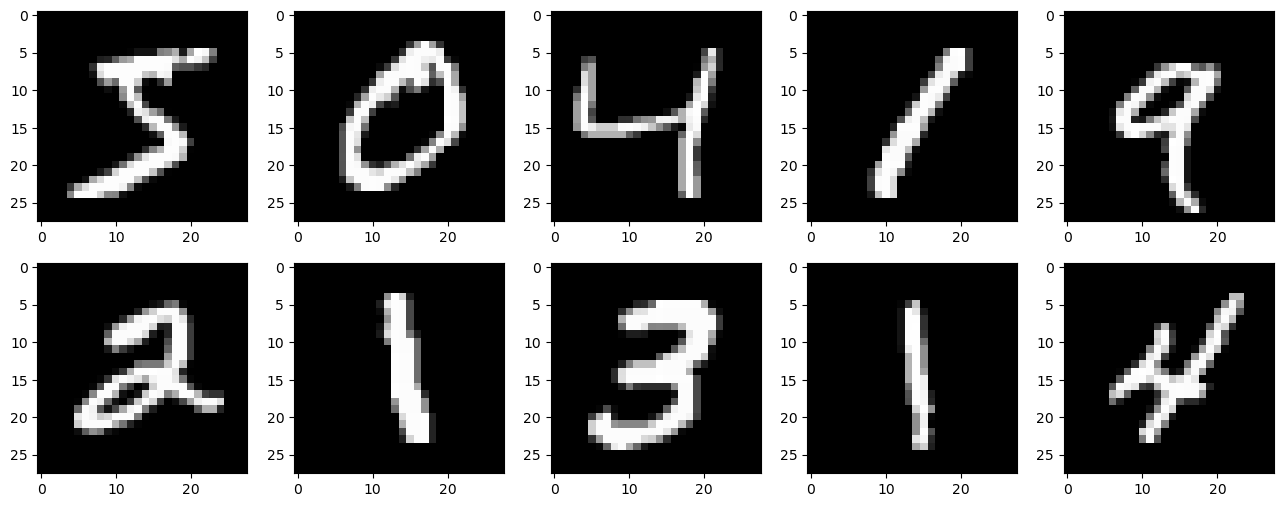

In [51]:
plt.figure(figsize=(16, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i,:].reshape([28,28]),  cmap='gray');
    plt.grid(False)

::: {.callout-note icon=false}

#### Shape of train_images

Inspect the code above and think about why we are reshaping `train_images[i,:]`

::: 

Since working with 60000 training images can be intensive, we will work with just 5000.

In [52]:
n_images = 5000
train_images = train_images[0:n_images, :, :]
train_labels = train_labels[0:n_images]
n_samples, n_rows, n_cols = train_images.shape

print(f"Number of images: {n_samples}, Image dimensions: {n_rows}x{n_cols}")

Number of images: 5000, Image dimensions: 28x28


In previous sessions, we got used to work with `X` and `Y`, so let's use them here as well. We will create again a test set of size 2500 from this slice of 5000.

In [53]:
# For training
X = np.reshape(train_images, (n_samples, n_rows * n_cols))
y_train = train_labels[0:int(n_images / 2)]
X_train = X[0 : int(n_images / 2), :]

# For test
X_test = X[int(n_images / 2) :, :]
y_test = train_labels[int(n_images / 2) :]

Once we have our train and test sets, we apply PCA. Now, the question you may have is how many principal components we should choose. 

To make a decision, we will perform PCA for different values of `n_components`. To define the range of `k`(number of components), we generate 10 evenly spaced integers between 1 and 75% of the rank of `X_train`. This range is chosen to explore different numbers of components for the dimensionality reduction, ensuring that the values are within a reasonable range relative to the rank of the matrix.

::: {.callout-note icon=false}

#### Rank of a matrix

The rank of a matrix is the maximum number of linearly independent rows or columns in the matrix.

::: 

In [54]:
X_rank = np.linalg.matrix_rank(X_train)
print('Rank of X_train:', X_rank)
K_linspace = np.linspace(1, 0.75 * X_rank, 10, dtype=int)
Ks = np.unique(np.append([1, 5, 10, 20], K_linspace))
Ks 

Rank of X_train: 632


array([  1,   5,  10,  20,  53, 106, 158, 211, 263, 316, 368, 421, 474])

In [55]:
RMSE_train = np.arange(len(Ks))
RMSE_test = np.arange(len(Ks))

The RMSE_train and RMSE_test arrays are initialized using `np.arange(len(Ks))`. These arrays will be used to store the **Root Mean Square Error (RMSE)** values for the training and testing datasets, respectively, for each value in Ks. 

This will help us to make a decision about the number of principal components to use.

In the code below, we will calculate the RMSE of the reconstruction of the training set. 

In [56]:
from sklearn.metrics import root_mean_squared_error
for index, K in enumerate(Ks):
    pca = PCA(n_components=K)

    Xtrain_transformed = pca.fit_transform(X_train)
    Xtrain_proj = pca.inverse_transform(Xtrain_transformed)
    RMSE_train[index] = root_mean_squared_error(X_train, Xtrain_proj)

    Xtest_transformed = pca.transform(X_test)
    Xtest_proj = pca.inverse_transform(Xtest_transformed)
    RMSE_test[index] = root_mean_squared_error(X_test, Xtest_proj)

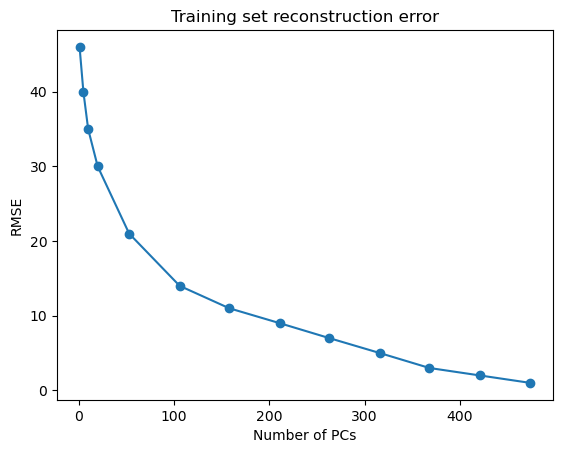

In [57]:
fig, ax = plt.subplots()
xs = Ks
ys = RMSE_train
plt.title("Training set reconstruction error")
plt.xlabel("Number of PCs")
plt.ylabel("RMSE")
ax.plot(xs, ys, marker="o")
plt.show()

In [58]:
elbow_index = np.argmin(np.abs(np.diff(RMSE_train)))
elbow_value = Ks[elbow_index]
print(elbow_value)

368


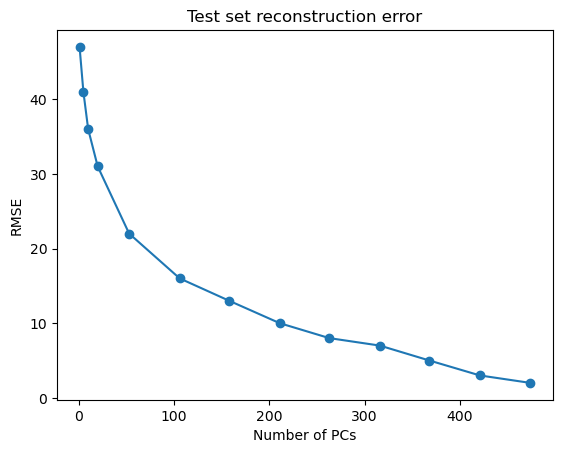

In [59]:
fig, ax = plt.subplots()
xs = Ks
ys = RMSE_test
plt.title("Test set reconstruction error")
plt.xlabel("Number of PCs")
plt.ylabel("RMSE")
ax.plot(xs, ys, marker="o")
plt.show()

As before, we have to also pay attention to the fraction of variance explained (considering the maximum number of principal components, which matches the rank of the matrix)

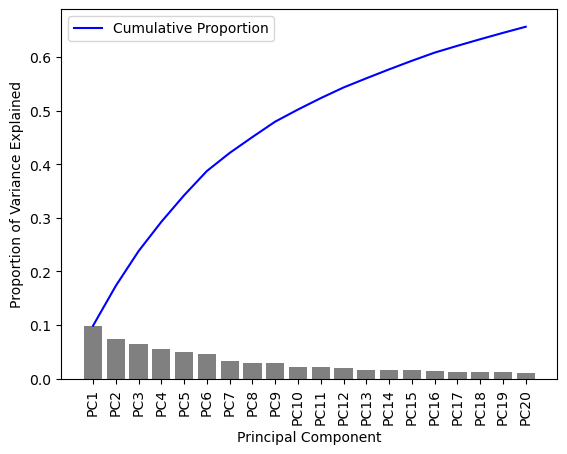

In [60]:
pca = PCA(n_components=X_rank)
X_transformed = pca.fit_transform(X_train)
evals = pca.explained_variance_  # eigenvalues in descending order

fraction_var = np.cumsum(evals[0:50] / np.sum(evals))

exp_variance = pd.DataFrame(data=pca.explained_variance_ratio_, index = ['PC' + str(n_pca + 1) for n_pca in range(pca.n_components)], columns=['Exp_variance'])
exp_variance['cum_Exp_variance'] = exp_variance['Exp_variance'].cumsum()
exp_variance = exp_variance.head(20)

sns.barplot(data=exp_variance, x=exp_variance.index, y='Exp_variance', color='gray')
sns.lineplot(data=exp_variance, x=exp_variance.index, y='cum_Exp_variance', color='blue', label='Cumulative Proportion')
plt.ylabel('Proportion of Variance Explained')
plt.xlabel('Principal Component')
plt.xticks(rotation=90)
plt.legend()
plt.show()

::: {.callout-note icon=false}

#### Selecting the optimal number of components

In order to choose the optimal number of components that ensures that the model effectively captures the underlying structure of the data, we have seen above that we can plot the training set reconstruction error (focusing on the elbow of the curve) and the proportion of variance explained by the principal componets. 

There is another option: to calculate **log likelihood**. The log-likelihood is a measure of how well a statistical model explains the observed data.

::: 

#### Log Likelihood to select optimal number of Principal Components

We will compute the log likelihood for different numbers of principal components using the eigenvalues of the covariance matrix. This approach involves dividing the eigenvalues into two groups and calculating the log likelihood based on the multivariate normal distribution.

In [61]:
from scipy.stats import multivariate_normal

def log_likelihood(evals):
    Lmax = len(evals)
    ll = np.zeros(Lmax)

    for L in range(Lmax):
        group1 = evals[0 : L + 1]  # Divide Eigenvalues in two groups
        group2 = evals[L + 1 : Lmax]

        mu1 = np.mean(group1)
        mu2 = np.mean(group2)

        sigma = (np.sum((group1 - mu1) ** 2) + np.sum((group2 - mu2) ** 2)) / Lmax

        ll_group1 = np.sum(multivariate_normal.logpdf(group1, mean=mu1, cov=sigma))
        ll_group2 = np.sum(multivariate_normal.logpdf(group2, mean=mu2, cov=sigma))

        ll[L] = ll_group1 + ll_group2  
    return ll

::: {.callout-note icon=false}

#### About the log likelihood calculation 
The function uses a multivariate normal distribution to calculate the log-likelihood of the eigenvalues because it assumes that the eigenvalues are normally distributed. By calculating the log-likelihood for different divisions of the eigenvalues, the function can compare different models and identify the division that maximizes the log-likelihood. This helps in determining the most likely separation of the eigenvalues under the normality assumption and, therefore, to understand how well our chosen number of principal components explains the data.

::: 

In [62]:
ll = log_likelihood(evals)

We will select the number of principal components that maximizes the log likelihood. This number represents the optimal balance between model complexity and data representation.

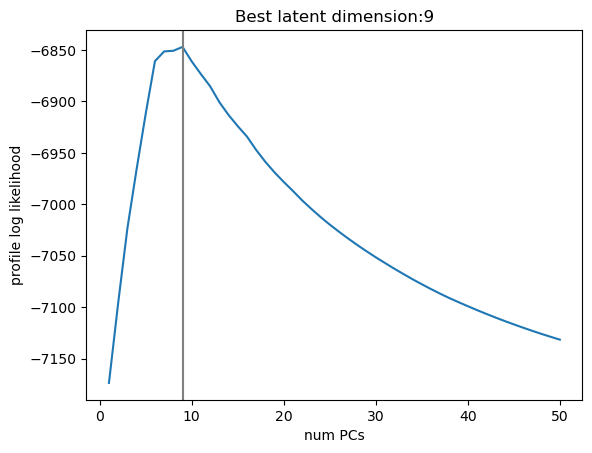

In [63]:
fig, ax = plt.subplots()
xs = np.arange(1, 51)
ys = ll[0:50]

plt.xlabel("num PCs")
plt.ylabel("profile log likelihood")
plt.plot(xs, ys)
idx = np.argmax(ys)
plt.axvline(xs[idx], c='grey')
plt.title('Best latent dimension:' + str(int(xs[idx])))
plt.show()

/tmp/ipykernel_10/3778614442.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_train, edgecolor='none', alpha=0.7, s=40, cmap=plt.cm.get_cmap('nipy_spectral', 10))


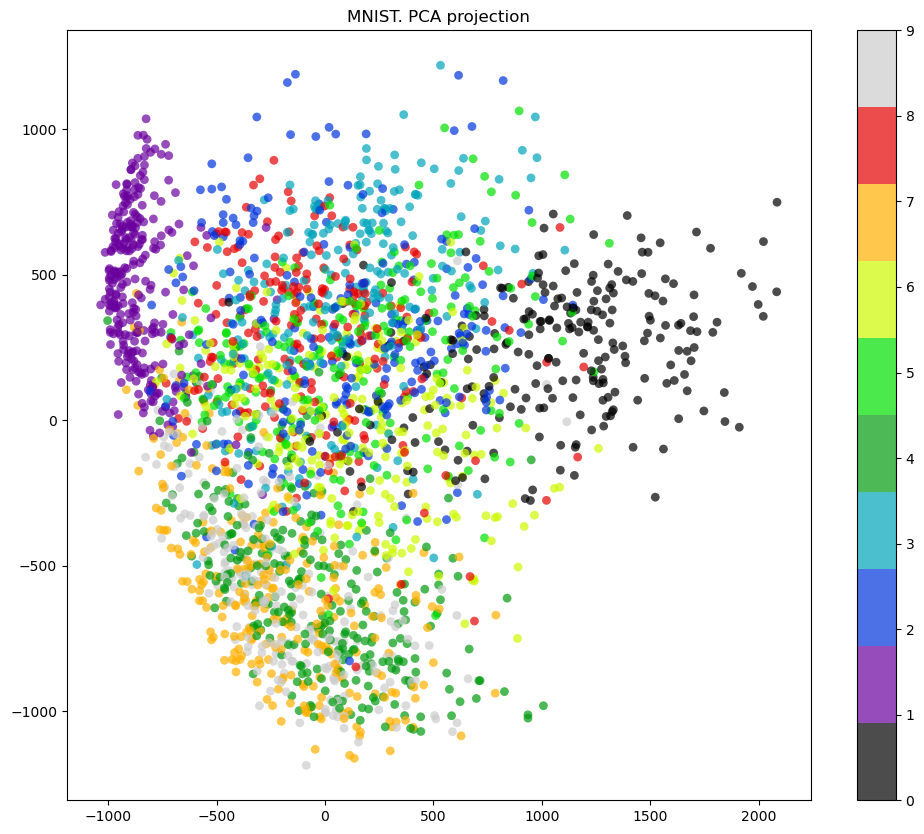

In [64]:
num_latent_dim = 2

pca = PCA(n_components=num_latent_dim)
X_reduced = pca.fit_transform(X_train)

plt.figure(figsize=(12,10))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_train, edgecolor='none', alpha=0.7, s=40, cmap=plt.cm.get_cmap('nipy_spectral', 10))
plt.colorbar()
plt.title('MNIST. PCA projection');
warnings.filterwarnings("ignore")

---

### **Example 4 (Labeled Faces in the Wild)**

We will use the Eigenfaces method to perform face recognition on the Labeled Faces in the Wild (LFW) dataset. We will use PCA to extract the eigenfaces and then use these eigenfaces for face recognition.


::: {.callout-note icon=false}

#### The Eigenfaces method
The Eigenfaces approach is a well-known method in computer vision for human face recognition. It involves using Principal Component Analysis (PCA) to reduce the dimensionality of face images and represent them as a combination of a small number of basis images, known as eigenfaces.

The eigenvectors obtained from PCA are called eigenfaces when applied to face images. Each eigenface represents a standardized face ingredient, and any face image can be approximated as a linear combination of these eigenfaces.

::: 


First, let's load the dataset

In [65]:
from sklearn.datasets import fetch_olivetti_faces
np.random.seed(0)
faces = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [66]:
img = faces['images']
X = faces['data']
target = faces['target']
y = np.ravel(np.repeat(np.arange(1, 41), 10))
# y is used to create a consistent set of labels for the dataset, where each of the 40 individuals has 10 images.

In [67]:
h, w, n = 64, 64, len(img)

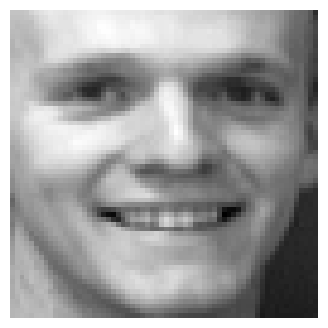

In [68]:
plt.figure(figsize=(4, 4)) 
plt.imshow(X[42].reshape(h, w), cmap='gray')
plt.axis('off')
plt.show()

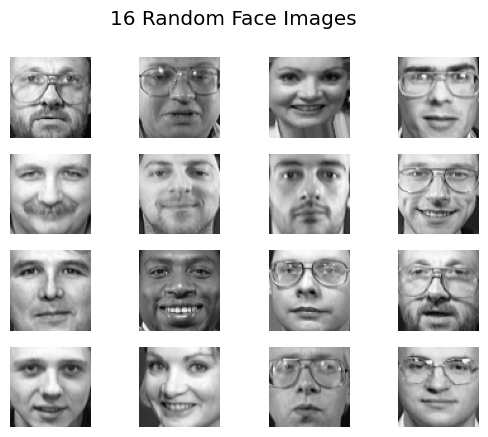

In [69]:
# Select 16 random faces
val = np.random.choice(n, 16, replace=False)
fig, axs = plt.subplots(4, 4)
fig.suptitle("16 Random Face Images ", fontsize="x-large")
for i in range(16):
    r, c = int(i / 4), i % 4
    axs[r, c].imshow(X[val[i]].reshape(h, w), cmap='gray')
    axs[r, c].axis('off')

Now, let's perform the PCA. First, we have to center the data by substracting its mean to X

In [70]:
print('Performing PCA')
mu = np.mean(X, axis=0)
XC = X - mu                 #X Centered

pca = PCA()
pca.fit(XC)
V = pca.components_
Z = np.dot(XC, V.T)

Performing PCA


Let's plot the "Mean" face and the first three Eigenfaces

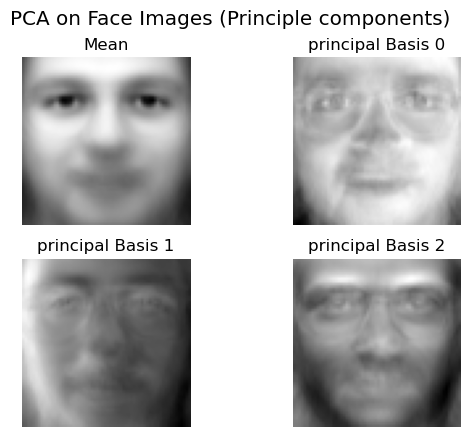

In [71]:
fig, axs = plt.subplots(2, 2)
fig.suptitle("PCA on Face Images (Principle components) ", fontsize="x-large")
for i in range(4):
    r, c = int(i / 2), i % 2
    if r == 0 and c == 0:
        # mu plot
        axs[r, c].imshow(mu.reshape(h, w), cmap='gray')
        axs[r, c].axis('off')
        axs[r, c].set_title('Mean')
    else:
        # plots the first three Eigenfaces (stored in V)
        axs[r, c].imshow(V[i - 1].reshape(h, w), cmap='gray')
        axs[r, c].axis('off')
        axs[r, c].set_title('principal Basis {}'.format(i - 1))

Now, let's check that if we do the inverse transform from a lower dimensional space, it will depend on the number of principal components we have chosen. 

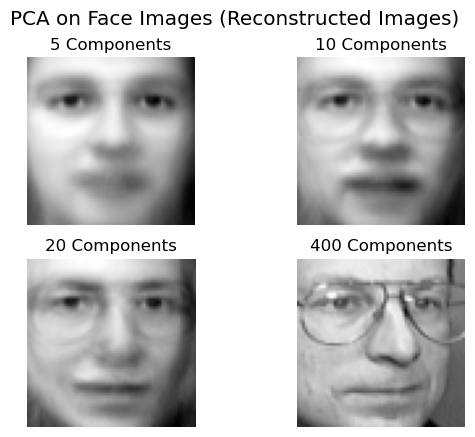

In [72]:
from numpy.linalg import matrix_rank
ndx = 125
Ks = [5, 10, 20, matrix_rank(X)]
fig, axs = plt.subplots(2, 2)
fig.suptitle("PCA on Face Images (Reconstructed Images) ", fontsize="x-large")
count = 0
for k in Ks:
    Xrecon = np.dot(Z[np.newaxis, ndx, :k], V[:k, :]) + mu
    r, c = int(count / 2), count % 2
    axs[r, c].imshow(Xrecon.reshape(64, 64), cmap='gray')
    axs[r, c].axis('off')
    axs[r, c].set_title('{} Components'.format(k))
    count += 1

In order to get a number about how good this is, let's plot the reconstruction error

Text(0.5, 0, 'K')

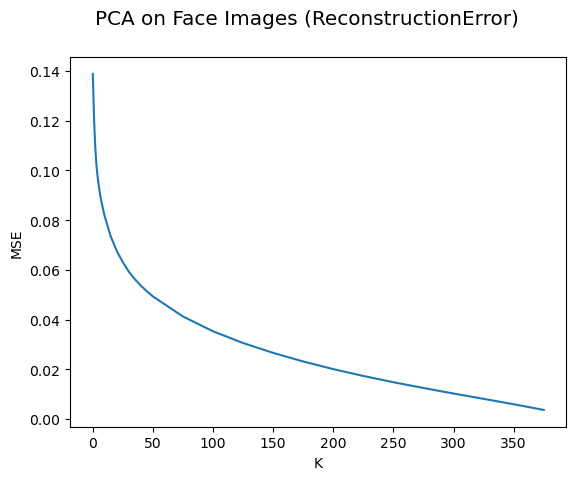

In [73]:
fig, axs = plt.subplots(1, 1)
fig.suptitle("PCA on Face Images (ReconstructionError) ", fontsize="x-large")
Ks = []
Ks.extend(list(np.arange(0, 10, 1)))
Ks.extend(list(np.arange(10, 50, 5)))
Ks.extend(list(np.arange(50, matrix_rank(X), 25)))
mse = np.zeros(len(Ks))
count = 0
for k in Ks:
    Xrecon = np.dot(Z[:, :k], V[:k, :]) + mu
    err = (Xrecon - X)
    mse[count] = np.sqrt(np.mean(err ** 2))
    count += 1

axs.plot(Ks, mse, '-')
axs.set_ylabel('MSE')
axs.set_xlabel('K')

::: {.callout-tip  icon=false}

#### Exercise 34.1.

Calculate the elbow of the reconstruction error curve

:::

In [74]:
elbow_index = np.argmin(np.abs(np.diff(mse))) +10
elbow_value = Ks[elbow_index]
print(elbow_value)

75


In [75]:
exp_variance = pd.DataFrame(data=pca.explained_variance_ratio_, index = ['PC' + str(n_pca + 1) for n_pca in range(len(pca.components_))], columns=['Exp_variance'])
exp_variance['cum_Exp_variance'] = exp_variance['Exp_variance'].cumsum()
exp_variance

,Exp_variance,cum_Exp_variance
PC1,2.381274e-01,0.238127
PC2,1.399397e-01,0.378067
PC3,7.968612e-02,0.457753
PC4,4.998330e-02,0.507736
PC5,3.609845e-02,0.543835
...,...,...
PC396,2.176395e-05,0.999942
PC397,2.141457e-05,0.999964
PC398,2.002387e-05,0.999984
PC399,1.639760e-05,1.000000


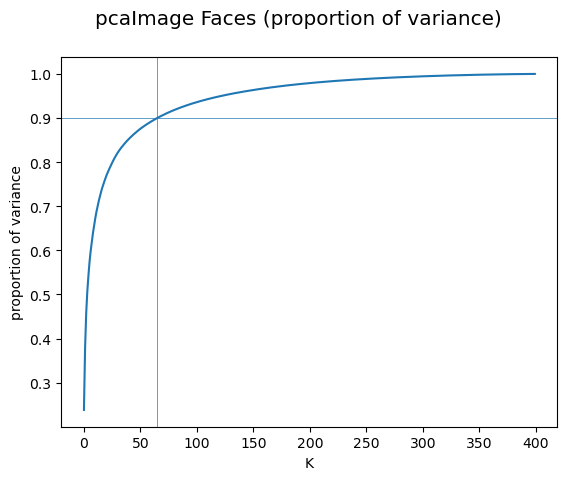

In [76]:
fig, axs = plt.subplots(1, 1)
fig.suptitle("pcaImage Faces (proportion of variance) ", fontsize="x-large")
exp_var = np.cumsum(pca.explained_variance_)/np.sum(pca.explained_variance_)
threshold = 0.90
idx_variance = np.where(exp_var>threshold)[0][0]
axs.plot(exp_var, '-')
axs.set_ylabel('proportion of variance')
axs.set_xlabel('K')
axs.axhline(threshold, linewidth=0.5)
axs.axvline(idx_variance, linewidth=0.5)

In [77]:
# Print the PCs
loadings = pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_), columns=['PC' + str(pca + 1) for pca in range(len(pca.components_))])
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC391,PC392,PC393,PC394,PC395,PC396,PC397,PC398,PC399,PC400
0,0.018192,0.095136,0.003407,0.002236,0.040294,0.045993,0.063220,0.008616,-0.031474,-0.022569,...,-0.000024,-0.000226,-0.000157,0.000232,0.000306,-0.000062,0.000912,0.000089,0.000618,-2.329980e-08
1,0.030859,0.110765,-0.000818,-0.003560,0.039869,0.049476,0.054288,0.004283,-0.044307,-0.025519,...,-0.000177,-0.000332,0.000271,-0.001201,0.000183,0.000608,0.000120,0.000819,0.001051,8.213632e-08
2,0.040524,0.125931,-0.000497,-0.023231,0.037452,0.045481,0.041878,-0.003566,-0.047526,-0.024320,...,-0.001146,-0.000136,-0.000438,-0.000619,0.000794,-0.000615,-0.000674,0.000603,-0.000339,-4.356776e-08
3,0.046055,0.131825,0.002662,-0.037110,0.033837,0.043307,0.032946,-0.009722,-0.039023,-0.020619,...,0.000789,-0.000300,0.000105,-0.000411,0.000188,-0.000747,-0.000018,0.000013,-0.000081,-3.546170e-08
4,0.049548,0.128901,0.007008,-0.047862,0.034002,0.040088,0.021786,-0.012677,-0.032475,-0.018161,...,-0.000812,-0.000932,0.000145,0.001438,-0.000454,0.000307,-0.000278,0.000147,0.000017,2.475079e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4091,0.007136,-0.101789,-0.049327,0.047408,0.058556,-0.026847,0.023267,-0.018011,0.021293,0.036742,...,0.001970,-0.002459,0.001333,0.003186,-0.000882,-0.001315,-0.001985,-0.000557,0.001439,-5.180731e-09
4092,-0.000830,-0.104870,-0.044323,0.050768,0.071195,-0.030648,0.026428,-0.003912,0.028878,0.032493,...,0.000982,-0.000889,0.000335,0.000186,-0.000066,-0.000348,0.000103,-0.000896,-0.000621,1.395931e-08
4093,-0.000804,-0.098584,-0.038702,0.058525,0.071722,-0.025853,0.032020,-0.005096,0.033739,0.027627,...,-0.001623,0.001311,-0.000366,-0.000233,-0.000205,0.000621,0.001859,-0.000507,0.000057,-2.935984e-08
4094,-0.014670,-0.090549,-0.034424,0.055322,0.067725,-0.025878,0.033360,-0.005139,0.035561,0.023040,...,-0.000080,0.001315,0.001265,-0.000586,0.002590,0.001822,0.000407,-0.002328,0.000450,1.431066e-08


You can use Eigenfaces to fuild a face recognition system. The idea is to project the faces into the lower dimensional space and then use a classifier to predict the person.
This is out of the scope of this course but, if you are interested, you can check the following website:

* https://machinelearningmastery.com/face-recognition-using-principal-component-analysis/ 